In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

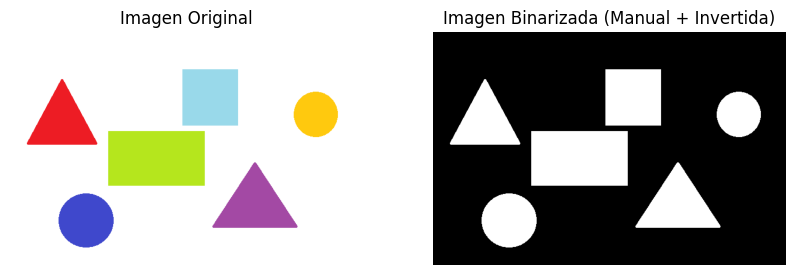

In [ ]:
# Cargar la imagen
image_path = '/content/Figuras.png'
original_image = cv2.imread(image_path)

# Verificar si la imagen se cargó correctamente
if original_image is None:
    print(f"Error: No se pudo cargar la imagen desde {image_path}")
else:
    # Convertir la imagen a escala de grises
    gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

    # Aplicar un umbral para binarizar la imagen
    # Usaremos un umbral manual alto y THRESH_BINARY_INV para que todo lo que no sea blanco puro
    # se convierta en blanco (figura) y el fondo blanco puro se convierta en negro.
    # El valor 240 es un buen punto de partida; ajusta si es necesario.
    _, binarized_loaded_image = cv2.threshold(gray_image, 240, 255, cv2.THRESH_BINARY_INV)

    # Mostrar la imagen original y la binarizada
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)) # Matplotlib espera RGB
    plt.title('Imagen Original')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(binarized_loaded_image, cmap='gray')
    plt.title('Imagen Binarizada (Manual + Invertida)')
    plt.axis('off')

    plt.show()

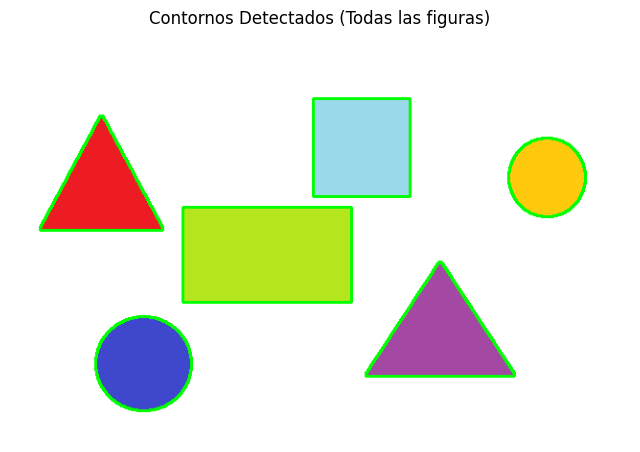

In [ ]:
# Encontrar contornos en la imagen binarizada
# cv2.findContours modifica la imagen de entrada, así que trabajamos con una copia
contours, hierarchy = cv2.findContours(binarized_loaded_image.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Crear una copia de la imagen original para dibujar los contornos
contours_image = original_image.copy()

# Dibujar todos los contornos encontrados
# El -1 indica que se dibujarán todos los contornos
# El color (0, 255, 0) es verde en BGR, y 2 es el grosor de la línea
cv2.drawContours(contours_image, contours, -1, (0, 255, 0), 2)

# Mostrar la imagen con los contornos detectados
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(contours_image, cv2.COLOR_BGR2RGB))
plt.title('Contornos Detectados (Todas las figuras)')
plt.axis('off')
plt.show()

Contour 1: Area = 7695.00, Perimeter = 328.05, Centroid = (139, 346)
Contour 2: Area = 9563.00, Perimeter = 456.62, Centroid = (448, 318)
Contour 3: Area = 17424.00, Perimeter = 550.00, Centroid = (268, 232)
Contour 4: Area = 5141.50, Perimeter = 268.35, Centroid = (560, 152)
Contour 5: Area = 7935.00, Perimeter = 419.02, Centroid = (95, 166)
Contour 6: Area = 10302.00, Perimeter = 406.00, Centroid = (366, 121)


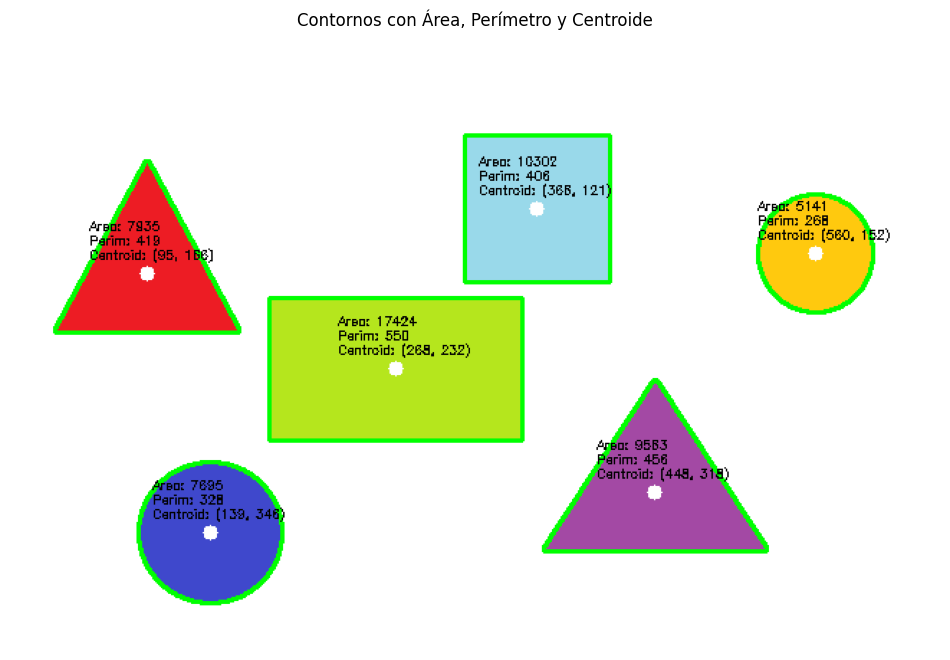

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Crear una copia de la imagen original para dibujar los contornos y las métricas
metrics_image = original_image.copy()

# Iterar sobre cada contorno detectado
for i, contour in enumerate(contours):
    # Calcular el área
    area = cv2.contourArea(contour)

    # Calcular el perímetro
    # El segundo argumento 'True' indica que el contorno está cerrado
    perimeter = cv2.arcLength(contour, True)

    # Calcular los momentos para encontrar el centroide
    M = cv2.moments(contour)

    # Evitar la división por cero si el área es muy pequeña (contorno no válido)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
    else:
        cX, cY = 0, 0  # Centroide predeterminado o manejar como un caso especial

    # Dibujar el contorno
    cv2.drawContours(metrics_image, [contour], -1, (0, 255, 0), 2) # Verde para los contornos

    # Dibujar el centroide como un círculo rojo
    if cX != 0 or cY != 0: # Solo dibujar si el centroide es válido
        cv2.circle(metrics_image, (cX, cY), 5, (255,255,255), -1)

    # Poner el texto con las métricas cerca del centroide
    text_area = f"Area: {int(area)}"
    text_perimeter = f"Perim: {int(perimeter)}"
    text_centroid = f"Centroid: ({cX}, {cY})"

    # Colocar el texto un poco por encima y debajo del centroide
    # Reducir el tamaño de la fuente (0.5 a 0.3) y cambiar el color a negro (0, 0, 0)
    cv2.putText(metrics_image, text_area, (cX - 40, cY - 30), cv2.FONT_HERSHEY_SIMPLEX, 0.28, (0, 0, 0), 1) # Negro
    cv2.putText(metrics_image, text_perimeter, (cX - 40, cY - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.28, (0, 0, 0), 1) # Negro
    cv2.putText(metrics_image, text_centroid, (cX - 40, cY - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.28, (0, 0, 0), 1) # Negro

    print(f"Contour {i+1}: Area = {area:.2f}, Perimeter = {perimeter:.2f}, Centroid = ({cX}, {cY})")

# Mostrar la imagen con los contornos y sus métricas
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(metrics_image, cv2.COLOR_BGR2RGB))
plt.title('Contornos con Área, Perímetro y Centroide')
plt.axis('off')
plt.show()